In [86]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


# ---- 1. load data ----
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = imdb.load_data(num_words=20000)


x_all = np.concatenate([x_train_raw, x_test_raw])
y_all = np.concatenate([y_train_raw, y_test_raw])


x_train, x_test = x_all[:40000], x_all[40000:]
y_train, y_test = y_all[:40000], y_all[40000:]

print(f"train size: {len(x_train)}")   # 40000
print(f"test size: {len(x_test)}")     # 10000
print(f"\nfirst review (first 10 words): {x_train[0][:10]}")
print(f"label: {y_train[0]}")

C:\Users\Admin\miniconda3\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


train size: 40000
test size: 10000

first review (first 10 words): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
label: 1


In [87]:
# ---- decode helper ----
word_index = imdb.get_word_index()
word_index_rev = {v: k for k, v in word_index.items()}

def decode(x):
    return " ".join([word_index_rev.get(i - 3, "?") for i in x])

In [88]:
# ---- 2. explore data ----

lengths = [len(x) for x in x_train]

print(f"\nmax len: {max(lengths)}")
print(f"min len: {min(lengths)}")
print(f"avg len: {int(np.mean(lengths))}")

print(f"\npositive: {np.sum(y_train == 1)}")
print(f"negative: {np.sum(y_train == 0)}")


max len: 2494
min len: 7
avg len: 236

positive: 19973
negative: 20027


In [89]:
# 2.1 first 5 reviews
print("\nfirst 5 reviews:")
for i in range(5):
    print(f"\nreview {i}:")
    print(decode(x_train[i]))
    print(f"label: {y_train[i]}")


first 5 reviews:

review 0:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and 

In [90]:
# 2.2random sample (use numpy instead of random)
idx = np.random.randint(0, len(x_train))
print("\nrandom review:")
print(decode(x_train[idx]))
print(f"label: {y_train[idx]}")


random review:
? spoilers br br well the one line summary says it all ? le samurai is the original and there are elements of leon and they are better much better br br in the samurai alain delon is a lonely warrior professional killer who keeps a bird in cage and is stealing cars for his jobs with so much suspense in these scenes even the end is exactly the same the samurai seeks death in dignity and is getting shot with an empty gun in his hand the world has changed he realizes and there is no place for the samurai in it br br delon is not killing so many people like the ghost dog but i guess jarmusch liked leon very much or even ? by rodriguez so he added this too and let me guess the girl will become a professional like ghost dog like natalie portman in leon br br so what was jarmusch thinking after all where is the unique the original thought in this movie br br i can´t see the point in making carbon celluloid copies br br a 4 10 rating by macaulay connor
label: 0


In [91]:
# 2.3short vs long
short_idx = np.argmin(lengths)
long_idx = np.argmax(lengths)

print("\nshort review:")
print(f"length: {len(x_train[short_idx])}")
print(decode(x_train[short_idx]))

print("\nlong review:")
print(f"length: {len(x_train[long_idx])}")
print(decode(x_train[long_idx]))

# short reviews contain limited information
# long reviews provide more context but may be truncated during padding



short review:
length: 7
? read the book forget the movie

long review:
length: 2494
? match 1 tag team table match bubba ray and spike dudley vs eddie guerrero and chris benoit bubba ray and spike dudley started things off with a tag team table match against eddie guerrero and chris benoit according to the rules of the match both opponents have to go through tables in order to get the win benoit and guerrero heated up early on by taking turns ? first spike and then bubba ray a german ? by benoit to bubba took the wind out of the dudley brother spike tried to help his brother but the referee restrained him while benoit and guerrero ? up on him in the corner with benoit stomping away on bubba guerrero set up a table outside spike dashed into the ring and ? over the top rope onto guerrero on the outside after recovering and taking care of spike guerrero slipped a table into the ring and helped the wolverine set it up the tandem then set up for a double ? from the middle rope which would 

In [92]:
# 2.4label vs length
pos_lengths = [len(x_train[i]) for i in range(len(x_train)) if y_train[i] == 1]
neg_lengths = [len(x_train[i]) for i in range(len(x_train)) if y_train[i] == 0]

print(f"\navg positive len: {int(np.mean(pos_lengths))}")
print(f"avg negative len: {int(np.mean(neg_lengths))}")

# positive reviews may be slightly longer on average


avg positive len: 238
avg negative len: 233


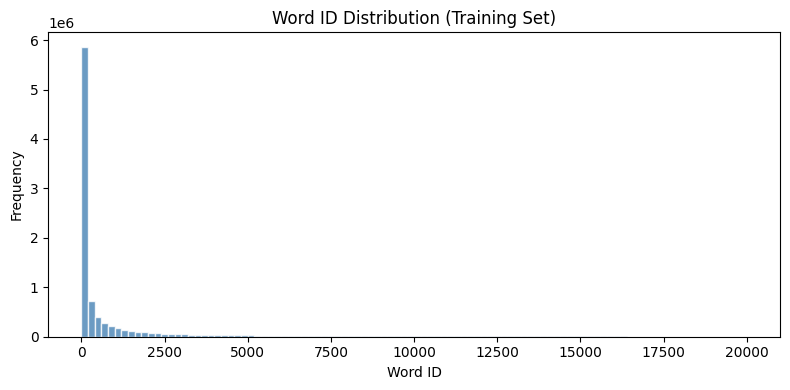

In [93]:
# 2.5 word id distribution
all_word_ids = [word_id for review in x_train for word_id in review]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_word_ids, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title("Word ID Distribution (Training Set)")
ax.set_xlabel("Word ID")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()
# not all 20000 words are actually used

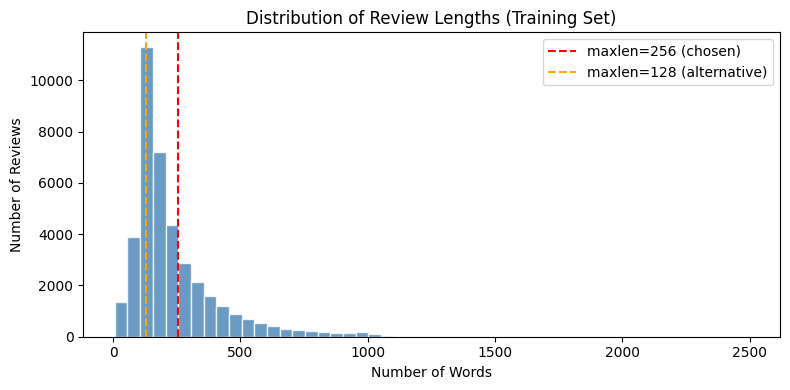

In [94]:
# 2.6visualize length
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title("Distribution of Review Lengths (Training Set)")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Number of Reviews")
ax.axvline(x=256, color='red', linestyle='--', label='maxlen=256 (chosen)')
ax.axvline(x=128, color='orange', linestyle='--', label='maxlen=128 (alternative)')
ax.legend()
plt.tight_layout()
plt.savefig("review_length_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [95]:
# ---- 3. padding ----

# use maxlen=256 as a balance between length and computation
x_train_pad = sequence.pad_sequences(x_train, maxlen=256)
x_test_pad = sequence.pad_sequences(x_test, maxlen=256)

# compare with smaller padding
x_train_pad_small = sequence.pad_sequences(x_train, maxlen=128)

print(f"\noriginal len: {len(x_train[0])}")
print(f"128 len: {len(x_train_pad_small[0])}")
print(f"256 len: {len(x_train_pad[0])}")

print("\npadded example:")
print(x_train_pad[0][:20])

# padding adds zeros to shorter sequences
# longer sequences are truncated, which may remove information


original len: 218
128 len: 128
256 len: 256

padded example:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [96]:
# ---- 4. build model ----
# Model design inspired by the IMDB sentiment example in:
# Géron, A. "Hands-On ML", 2rd ed., Chapter 16.
# Key differences: GlobalAveragePooling1D instead of GRU (faster baseline),
# added Dropout(0.5), adam instead of nadam, embedding_dim=32 instead of 128.
model = keras.Sequential()

# embedding layer
model.add(keras.layers.Embedding(20000, 32))
# embedding_dim=32: smaller than the book's 128 because GlobalAveragePooling1D
# is a simpler aggregation than GRU and does not require as rich an embedding space.

model.add(keras.layers.GlobalAveragePooling1D())


# dense layer
model.add(keras.layers.Dense(64, activation='relu'))
#Dense(64): sufficient capacity for a simple averaged-embedding representation

# dropout
model.add(keras.layers.Dropout(0.5))
# Dropout(0.5): regularization after the only Dense layer to reduce overfitting

# output layer
model.add(keras.layers.Dense(1, activation='sigmoid'))

print(model.summary())

# simple baseline model, can be extended later if needed

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_21          │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [97]:
# ---- 5. compile ----
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [98]:
# ---- 6. train with CV ----
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train_pad, y_train)): 
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    
    x_tr, x_val = x_train_pad[train_idx], x_train_pad[val_idx]  
    y_tr, y_val = y_train[train_idx], y_train[val_idx]           
    
    model = keras.Sequential([
        keras.layers.Embedding(20000, 32),
        keras.layers.GlobalAveragePooling1D(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)
    
    history = model.fit(x_tr, y_tr,
              epochs=10,
              batch_size=512,
              validation_data=(x_val, y_val),
              callbacks=[early_stop],
              verbose=0)
    
    _, acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Fold {fold+1} val accuracy: {acc:.4f}")
    cv_scores.append(acc)

print(f"\nCV mean accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


--- Fold 1/5 ---
Fold 1 val accuracy: 0.8830

--- Fold 2/5 ---
Fold 2 val accuracy: 0.8725

--- Fold 3/5 ---
Fold 3 val accuracy: 0.8884

--- Fold 4/5 ---
Fold 4 val accuracy: 0.8770

--- Fold 5/5 ---
Fold 5 val accuracy: 0.8930

CV mean accuracy: 0.8828 ± 0.0074


In [99]:
# ---- 7. evaluate ----
test_loss, test_acc = model.evaluate(x_test_pad, y_test)
print(f"\ntest accuracy: {test_acc:.4f}")


pred_probs = model.predict(x_test_pad)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, pred_labels, target_names=['Negative', 'Positive']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8942 - loss: 0.2617

test accuracy: 0.8942
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4973
    Positive       0.88      0.91      0.90      5027

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



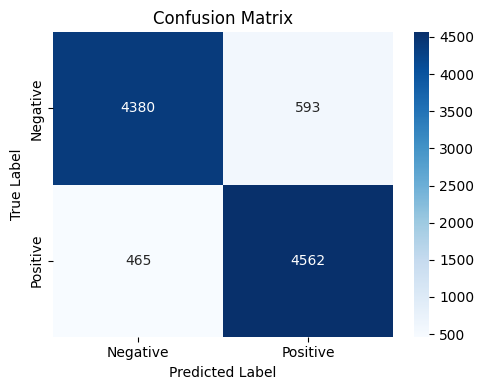

In [100]:
# ---- 7b. evaluate ----

import seaborn as sns

cm = confusion_matrix(y_test, pred_labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# confusion matrix shows distribution of correct and incorrect predictions
# useful for identifying false positives and false negatives


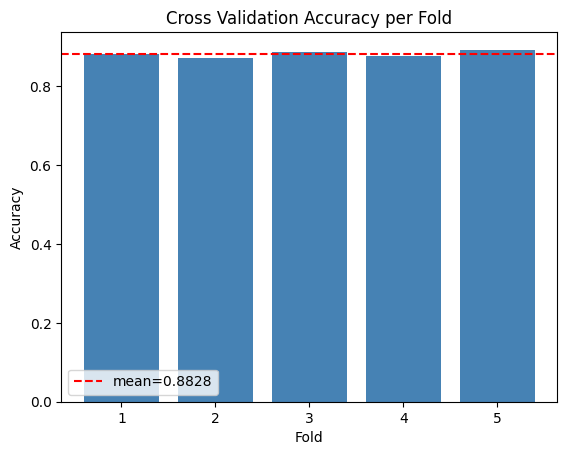

In [101]:
# ---- 8. plot CV results ----
plt.figure()
plt.bar(range(1, n_splits+1), cv_scores, color='steelblue')
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f'mean={np.mean(cv_scores):.4f}')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross Validation Accuracy per Fold")
plt.legend()
plt.show()

In [102]:
model.save("imdb_model.keras")
print("\nmodel saved")


model saved
